In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [39]:
df = pd.read_excel("..//Data/ENB2012_data.xlsx")

In [40]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


No label for the Columns, adding names

In [41]:
df.columns = df.columns.str.strip()

In [42]:
df.columns = ["Relative_Compactness","Surface_Area","Wall_Area","Roof_Area","Overall_Height","Orientation","Glazing_Area","Glazing_Distribution","Heating_Load","Cooling_Load"]


In [43]:
df.head(10)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [44]:
df[df['Glazing_Area'] == 0]
len(df[df['Glazing_Area'] == 0])

48

-0 value in Glazing_Area and Glazing_Distribution
-Glazing_Area is ratio for window -> wall
-Glazing_distribution is how are the windows located.
IS the zero important?
The zero reading is important as building a baseline, so not to be removed.

In [45]:
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Relative_Compactness  768 non-null    float64
 1   Surface_Area          768 non-null    float64
 2   Wall_Area             768 non-null    float64
 3   Roof_Area             768 non-null    float64
 4   Overall_Height        768 non-null    float64
 5   Orientation           768 non-null    int64  
 6   Glazing_Area          768 non-null    float64
 7   Glazing_Distribution  768 non-null    int64  
 8   Heating_Load          768 non-null    float64
 9   Cooling_Load          768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [47]:
df.isna().sum()


Relative_Compactness    0
Surface_Area            0
Wall_Area               0
Roof_Area               0
Overall_Height          0
Orientation             0
Glazing_Area            0
Glazing_Distribution    0
Heating_Load            0
Cooling_Load            0
dtype: int64

There is no null/na

In [48]:
df.duplicated().sum()


np.int64(0)

This is no duplicate

In [49]:
df.groupby('Orientation').size()

Orientation
2    192
3    192
4    192
5    192
dtype: int64

-fair exposure, each orientation have same number.
Did not find the index for the orientation. 
-Data is simulated in Ecotect, not collected in reallife.
    -real life orientation should have some favor towards to sun(also depends on geo-location)
-Both Orientation(where the house is facing) and Window_Dis(how is window placed) is catgory
    need to change the data type. -dummy Encoding (One-Hot is for 1-0)

<Axes: xlabel='Heating_Load', ylabel='Glazing_Area'>

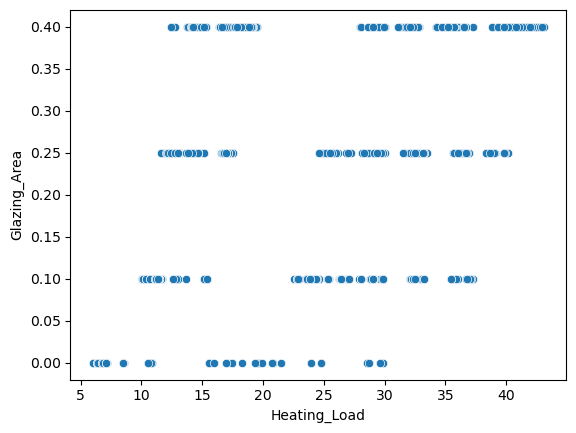

In [50]:
sns.scatterplot(data=df, x='Heating_Load', y ='Glazing_Area')

Glazing Area have limited results(0,0.1,0.25,and 0.4)
It is a ratio , Maybe also dummy it? 
It is programmed this way, not real life.


In [51]:
g25 = len(df[df['Glazing_Area'] == 0.25])
g0= len(df[df['Glazing_Area'] == 0.0])
g1=len(df[df['Glazing_Area'] == 0.10])
g4=len(df[df['Glazing_Area'] == 0.4])

print(g0,g1,g25,g4)

48 240 240 240


Once again fair distribution of category, 0 is the baseline.

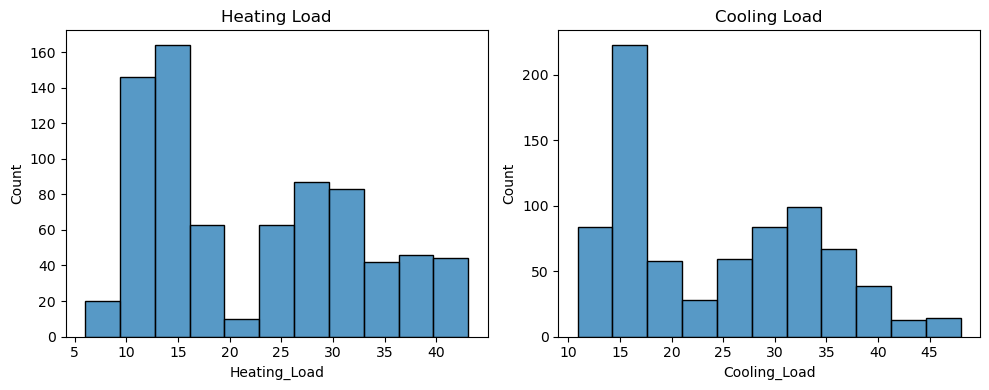

In [52]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
sns.histplot(data=df, x="Heating_Load", ax=axes[0])
sns.histplot(data=df, x="Cooling_Load", ax=axes[1])

axes[0].set_title("Heating Load")
axes[1].set_title("Cooling Load")

plt.tight_layout()
plt.show()


Both heating and cooling distribution are following Bimodal.

In [53]:
df['Overall_Height'].value_counts()

Overall_Height
7.0    384
3.5    384
Name: count, dtype: int64

The height is limited to 2 values, it seems to be contributing the bimodal distribution.
the height of 3.5 ad 7 meter, in real life it should be 1-story and 2-story.

In [54]:
df.columns

Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution',
       'Heating_Load', 'Cooling_Load'],
      dtype='str')

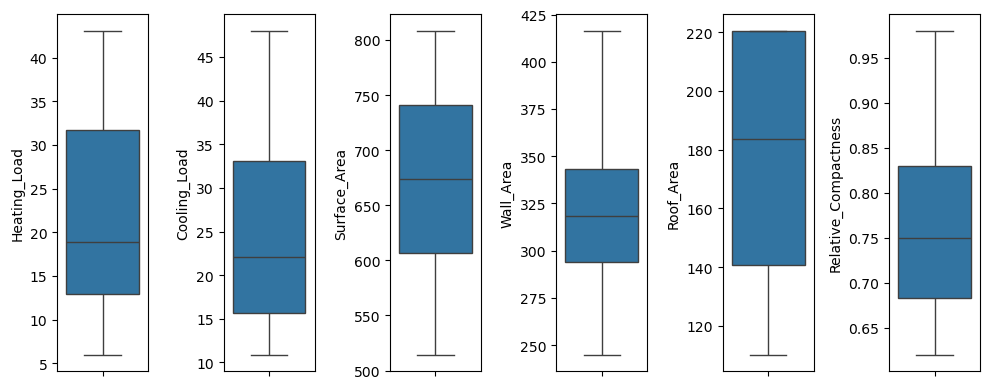

In [57]:
fig, axes = plt.subplots(1,6, figsize=(10,4))
sns.boxplot(df["Heating_Load"], ax=axes[0])
sns.boxplot(df["Cooling_Load"], ax=axes[1])
sns.boxplot(df["Surface_Area"], ax=axes[2])
sns.boxplot(df["Wall_Area"], ax=axes[3])
sns.boxplot(df["Roof_Area"], ax=axes[4])
sns.boxplot(df["Relative_Compactness"], ax=axes[5])



plt.tight_layout()
plt.show()

1- There are no outliers with the number features
2- The Heating and Cooling both showing the a right skewed distribution, matching the histogram. There are more lower value datas, while there are large data to even out the calculation. 
3-Roof_Area seems to be kept at a range 

<Axes: >

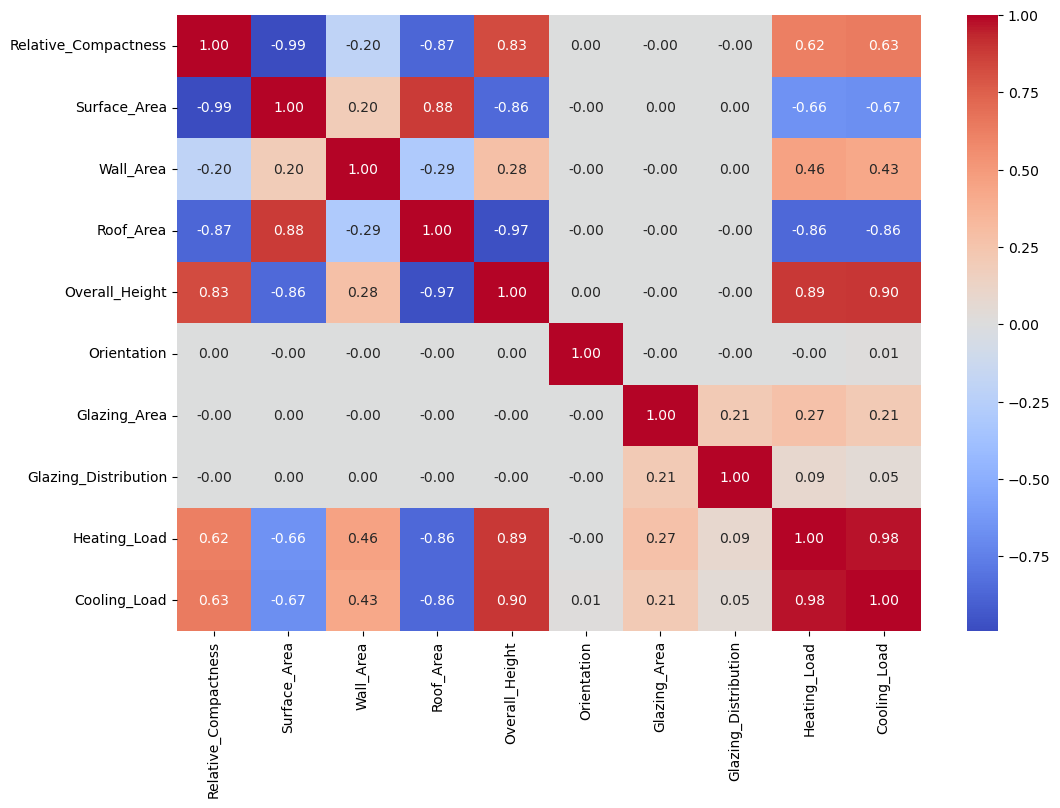

In [56]:
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True,fmt='.2f', cmap='coolwarm')


It seems that most of features have high corelation, higher than 0.5.
As we know Relative_Comp calculated with Surface Area
Surface Area inlcudes Wall-Roof

The dataset is clean by it self, however there are several traps.
1- category - numerical values (Orientaion, Glazing_Dis)
2- The dataset is not real life data, it is simulated, thus lots of parameters and so datas tend to show alike values
3- there are direct relation between values, 
    Surface_Area includes Wall_Area and Roof_Area
    Relative_Compactness calculation includes Surface Area
    Need to choose what to drop when comes to regression .
4- There is 2 groups within the dataset, seperated by the Height
5- There is 2 targets to be analyzed, Cooling and Heating 